In [1]:
import os
import gzip
import math
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path("../data/tsp")
DATA_DIR.mkdir(parents=True, exist_ok=True)

TSP_NAME = "berlin52"
TSP_URL = "https://comopt.ifi.uni-heidelberg.de/software/TSPLIB95/tsp/berlin52.tsp.gz"

tsp_path = DATA_DIR / f"{TSP_NAME}.tsp.gz"

if not tsp_path.exists():
    print("Downloading berlin52 dataset...")
    urllib.request.urlretrieve(TSP_URL, tsp_path)
    print("Download complete.")
else:
    print("Dataset already exists.")

print(tsp_path)

Download complete.
../data/tsp/berlin52.tsp.gz


In [3]:
def open_tsp_file(path):
    """
    Opens normal .tsp files and compressed .tsp.gz files.
    """
    path = Path(path)
    
    if path.suffix == ".gz":
        return gzip.open(path, "rt")
    
    return open(path, "r")


def parse_tsplib_tsp(path):
    """
    Parses a TSPLIB .tsp file that has a NODE_COORD_SECTION.
    Returns metadata and city coordinates.
    """
    metadata = {}
    coordinates = []
    reading_coords = False
    
    with open_tsp_file(path) as file:
        for line in file:
            line = line.strip()
            
            if line == "":
                continue
            
            if line == "NODE_COORD_SECTION":
                reading_coords = True
                continue
            
            if line == "EOF":
                break
            
            if reading_coords:
                parts = line.split()
                
                city_id = int(parts[0])
                x = float(parts[1])
                y = float(parts[2])
                
                coordinates.append((city_id, x, y))
            
            else:
                if ":" in line:
                    key, value = line.split(":", 1)
                    metadata[key.strip()] = value.strip()
    
    coords_df = pd.DataFrame(coordinates, columns=["City", "X", "Y"])
    
    return metadata, coords_df

In [4]:
metadata, coords_df = parse_tsplib_tsp(tsp_path)

print(metadata)
coords_df.head()

{'NAME': 'berlin52', 'TYPE': 'TSP', 'COMMENT': '52 locations in Berlin (Groetschel)', 'DIMENSION': '52', 'EDGE_WEIGHT_TYPE': 'EUC_2D'}


,City,X,Y
0,1,565.0,575.0
1,2,25.0,185.0
2,3,345.0,750.0
3,4,945.0,685.0
4,5,845.0,655.0


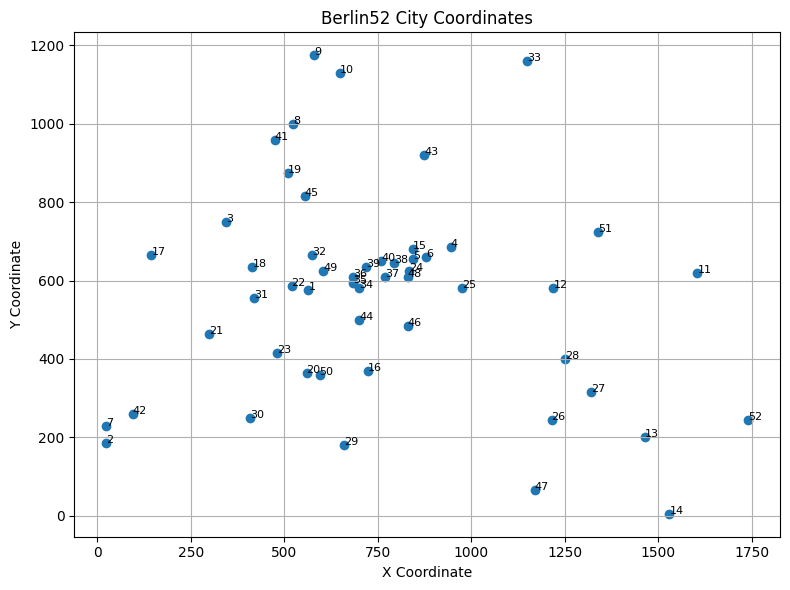

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(coords_df["X"], coords_df["Y"])

for _, row in coords_df.iterrows():
    plt.text(row["X"], row["Y"], str(int(row["City"])), fontsize=8)

plt.title("Berlin52 City Coordinates")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.grid(True)
plt.tight_layout()

plt.savefig("berlin52_city_coordinates.png", dpi=300)
plt.show()

In [6]:
def tsplib_euclidean_distance(city_a, city_b):
    """
    Calculates TSPLIB EUC_2D distance.
    Distance is rounded to the nearest integer.
    """
    x1, y1 = city_a
    x2, y2 = city_b
    
    distance = math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
    
    return int(math.floor(distance + 0.5))


def create_distance_matrix(coords_df):
    """
    Creates a distance matrix between all cities.
    """
    coordinates = coords_df[["X", "Y"]].values
    n = len(coordinates)
    
    distance_matrix = np.zeros((n, n), dtype=int)
    
    for i in range(n):
        for j in range(n):
            distance_matrix[i][j] = tsplib_euclidean_distance(
                coordinates[i],
                coordinates[j]
            )
    
    return distance_matrix


distance_matrix = create_distance_matrix(coords_df)

distance_matrix[:5, :5]

array([[   0,  666,  281,  396,  291],
       [ 666,    0,  649, 1047,  945],
       [ 281,  649,    0,  604,  509],
       [ 396, 1047,  604,    0,  104],
       [ 291,  945,  509,  104,    0]])

In [7]:
def calculate_route_distance(route, distance_matrix):
    """
    Calculates total route distance.
    The route returns to the starting city at the end.
    """
    total_distance = 0
    
    for i in range(len(route)):
        current_city = route[i]
        next_city = route[(i + 1) % len(route)]
        
        total_distance += distance_matrix[current_city][next_city]
    
    return total_distance

In [8]:
np.random.seed(42)

number_of_cities = len(coords_df)

initial_route = np.random.permutation(number_of_cities).tolist()

initial_distance = calculate_route_distance(initial_route, distance_matrix)

print("Initial route:")
print(initial_route)

print("\nInitial distance:", initial_distance)

Initial route:
[19, 41, 47, 12, 43, 5, 17, 50, 3, 32, 13, 8, 26, 6, 34, 4, 37, 24, 44, 33, 49, 15, 9, 16, 30, 36, 25, 11, 0, 46, 27, 31, 39, 29, 45, 1, 21, 2, 40, 35, 23, 48, 10, 22, 18, 51, 20, 7, 42, 14, 28, 38]

Initial distance: 30301


In [9]:
def plot_route(coords_df, route, title, filename):
    """
    Plots a TSP route and saves it as a PNG image.
    """
    ordered_coords = coords_df.iloc[route]
    
    x_values = ordered_coords["X"].tolist()
    y_values = ordered_coords["Y"].tolist()
    
    # Return to the starting city
    x_values.append(x_values[0])
    y_values.append(y_values[0])
    
    plt.figure(figsize=(9, 7))
    
    plt.plot(x_values, y_values, marker="o")
    
    plt.title(title)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.grid(True)
    plt.tight_layout()
    
    plt.savefig(filename, dpi=300)
    plt.show()

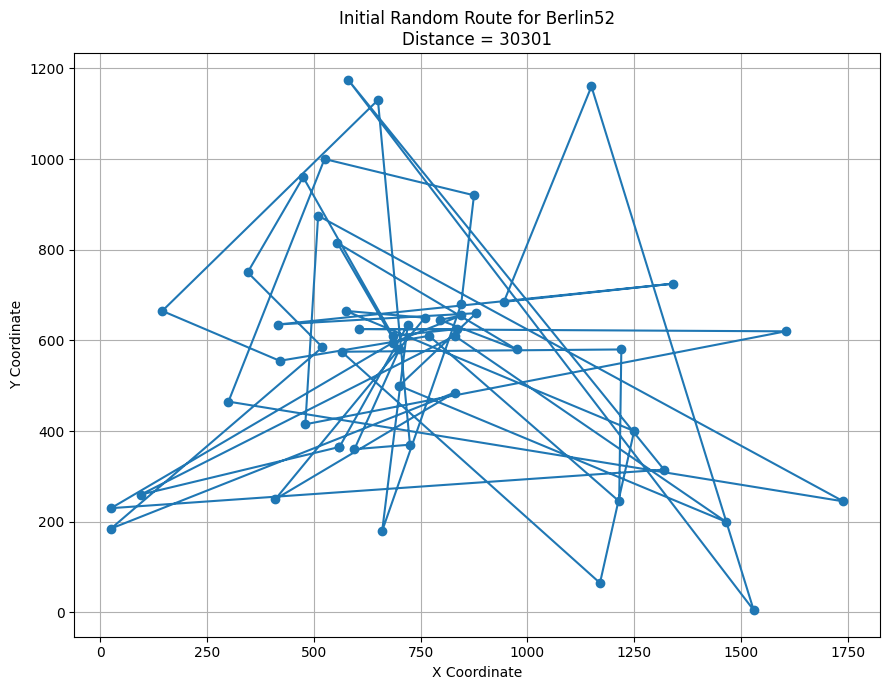

In [10]:
plot_route(
    coords_df,
    initial_route,
    f"Initial Random Route for Berlin52\nDistance = {initial_distance}",
    "berlin52_initial_random_route.png"
)

In [11]:
def hill_climbing_2opt(initial_route, distance_matrix, max_passes=1000):
    """
    Hill Climbing algorithm for TSP using 2-opt swaps.
    
    A 2-opt swap reverses part of the route.
    If the new route is shorter, the move is accepted.
    If it is not shorter, the move is rejected.
    """
    current_route = initial_route.copy()
    current_distance = calculate_route_distance(current_route, distance_matrix)
    
    n = len(current_route)
    
    distance_history = [current_distance]
    
    for pass_number in range(max_passes):
        improvement_found = False
        
        for i in range(1, n - 1):
            for k in range(i + 1, n):
                
                # Current edges:
                # A -> B and C -> D
                A = current_route[i - 1]
                B = current_route[i]
                C = current_route[k]
                D = current_route[(k + 1) % n]
                
                # New edges after reversing route[i:k+1]:
                # A -> C and B -> D
                old_distance = distance_matrix[A][B] + distance_matrix[C][D]
                new_distance = distance_matrix[A][C] + distance_matrix[B][D]
                
                distance_change = new_distance - old_distance
                
                # Accept only if the neighbour is better
                if distance_change < 0:
                    current_route[i:k + 1] = current_route[i:k + 1][::-1]
                    current_distance += distance_change
                    
                    distance_history.append(current_distance)
                    improvement_found = True
                    
                    break
            
            if improvement_found:
                break
        
        # Stop if no better neighbour was found
        if not improvement_found:
            break
    
    return current_route, current_distance, distance_history

In [12]:
best_route, best_distance, distance_history = hill_climbing_2opt(
    initial_route,
    distance_matrix
)

print("Initial distance:", initial_distance)
print("Final distance after Hill Climbing:", best_distance)

improvement = initial_distance - best_distance
improvement_percentage = (improvement / initial_distance) * 100

print("Improvement:", improvement)
print("Improvement percentage:", round(improvement_percentage, 2), "%")
print("Number of accepted improvements:", len(distance_history) - 1)

Initial distance: 30301
Final distance after Hill Climbing: 8287
Improvement: 22014
Improvement percentage: 72.65 %
Number of accepted improvements: 174


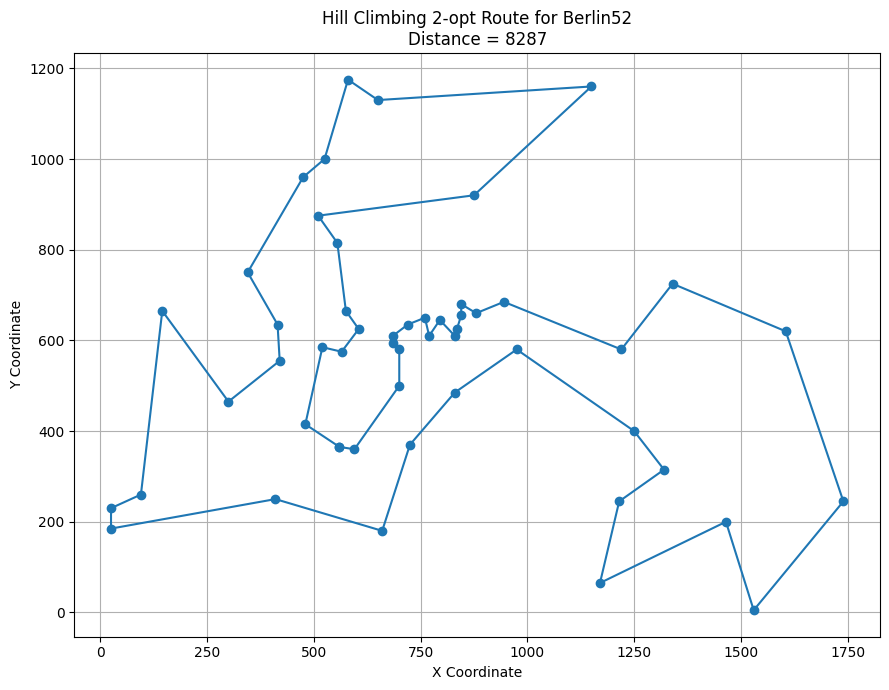

In [13]:
plot_route(
    coords_df,
    best_route,
    f"Hill Climbing 2-opt Route for Berlin52\nDistance = {best_distance}",
    "berlin52_hill_climbing_final_route.png"
)

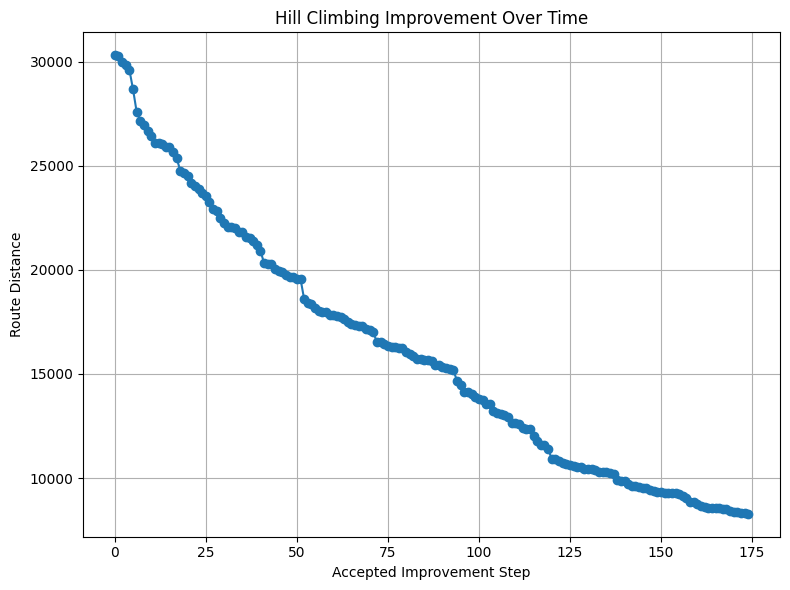

In [14]:
plt.figure(figsize=(8, 6))

plt.plot(distance_history, marker="o")

plt.title("Hill Climbing Improvement Over Time")
plt.xlabel("Accepted Improvement Step")
plt.ylabel("Route Distance")
plt.grid(True)
plt.tight_layout()

plt.savefig("berlin52_hill_climbing_improvement_graph.png", dpi=300)
plt.show()

In [15]:
def random_restart_hill_climbing(distance_matrix, number_of_restarts=20, seed=42):
    """
    Runs Hill Climbing multiple times using different random starting routes.
    Keeps the best result.
    """
    np.random.seed(seed)
    
    n = distance_matrix.shape[0]
    
    best_overall_route = None
    best_overall_distance = float("inf")
    best_overall_history = None
    
    restart_results = []
    
    for restart in range(number_of_restarts):
        random_route = np.random.permutation(n).tolist()
        starting_distance = calculate_route_distance(random_route, distance_matrix)
        
        route, final_distance, history = hill_climbing_2opt(
            random_route,
            distance_matrix
        )
        
        restart_results.append({
            "Restart": restart + 1,
            "Starting Distance": starting_distance,
            "Final Distance": final_distance,
            "Improvement": starting_distance - final_distance
        })
        
        if final_distance < best_overall_distance:
            best_overall_route = route
            best_overall_distance = final_distance
            best_overall_history = history
    
    restart_results_df = pd.DataFrame(restart_results)
    
    return best_overall_route, best_overall_distance, best_overall_history, restart_results_df

In [16]:
rr_best_route, rr_best_distance, rr_history, restart_results_df = random_restart_hill_climbing(
    distance_matrix,
    number_of_restarts=20,
    seed=42
)

restart_results_df

,Restart,Starting Distance,Final Distance,Improvement
0,1,30301,8287,22014
1,2,31079,8021,23058
2,3,32321,7844,24477
3,4,29767,7867,21900
4,5,30856,7922,22934
5,6,31448,8581,22867
6,7,30685,7836,22849
7,8,31370,8393,22977
8,9,30958,7867,23091
9,10,28853,8129,20724


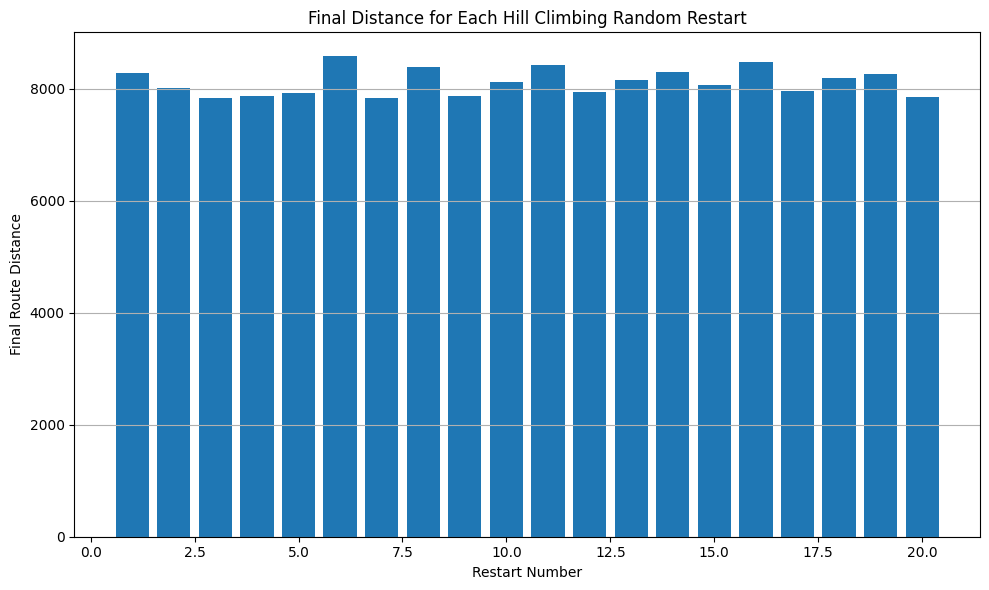

Best distance from random restarts: 7836


In [17]:
plt.figure(figsize=(10, 6))

plt.bar(
    restart_results_df["Restart"],
    restart_results_df["Final Distance"]
)

plt.title("Final Distance for Each Hill Climbing Random Restart")
plt.xlabel("Restart Number")
plt.ylabel("Final Route Distance")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig("berlin52_hill_climbing_random_restarts.png", dpi=300)
plt.show()

print("Best distance from random restarts:", rr_best_distance)

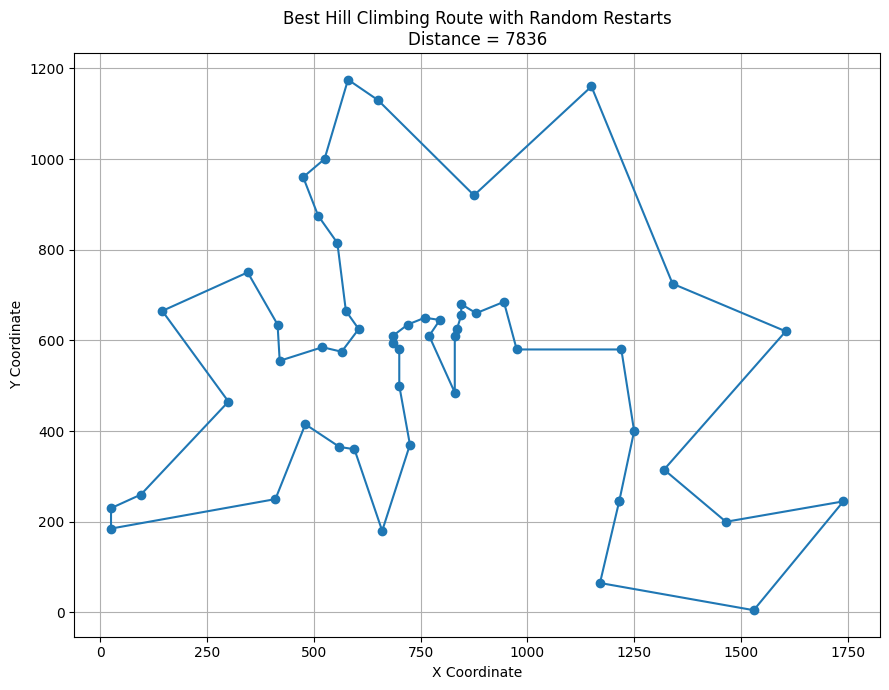

In [18]:
plot_route(
    coords_df,
    rr_best_route,
    f"Best Hill Climbing Route with Random Restarts\nDistance = {rr_best_distance}",
    "berlin52_best_hill_climbing_random_restart_route.png"
)